In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("spam.csv")

In [3]:
df.sample(5)

,Category,Message
5051,ham,I will vote for wherever my heart guides me
2952,ham,Hey now am free you can call me.
3653,ham,"Probably not, still going over some stuff here"
2490,ham,I have 2 docs appointments next week.:/ I'm ti...
1592,ham,That's my honeymoon outfit. :)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Category"] = encoder.fit_transform(df["Category"])

In [6]:
df.sample(5)

,Category,Message
5546,0,Ic. There are a lotta childporn cars then.
2713,0,Hey you still want to go for yogasana? Coz if ...
3902,0,That depends. How would you like to be treated...
4066,0,Dont kick coco when he's down
1871,0,"Aight, I'll text you when I'm back"


In [7]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(415)

In [9]:
df = df.drop_duplicates(keep="first")

In [10]:
df.duplicated().sum()

np.int64(0)

### EDA (Exploratory Data Analysis) :-


In [11]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df['Category'].value_counts()

Category
0    4516
1     641
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x14d9ab481a0>,
 [Text(-1.0171946362150524, 0.41870642705280725, 'ham'),
  Text(1.0171945729921292, -0.4187065806449194, 'spam')],
 [Text(-0.554833437935483, 0.22838532384698573, '87.57'),
  Text(0.5548334034502522, -0.22838540762450146, '12.43')])

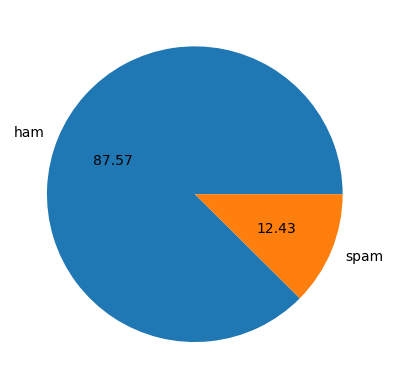

In [13]:
plt.pie(df['Category'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")

In [14]:
!pip install nltk

In [15]:
df['num_characters'] = df['Message'].apply(len)
df['num_characters']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    160
5568     36
5569     57
5570    125
5571     26
Name: num_characters, Length: 5157, dtype: int64

In [16]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [17]:
# calculating the number of words in each message
df['num_words'] = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_words']

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: num_words, Length: 5157, dtype: int64

In [18]:
#  calculating the number of sentences in each message
df['num_sentences'] = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))
df['num_sentences']

0       2
1       2
2       2
3       1
4       1
       ..
5567    4
5568    1
5569    2
5570    1
5571    2
Name: num_sentences, Length: 5157, dtype: int64

In [19]:
# describing the new features
df[['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,18.560791,79.103936,1.969750
std,13.406330,58.382922,1.455526
min,1.000000,2.000000,1.000000
25%,9.000000,36.000000,1.000000
50%,15.000000,61.000000,1.000000
75%,26.000000,118.000000,2.000000
max,220.000000,910.000000,38.000000


In [20]:
# describing ham messages
df[df['Category'] == 0][['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,17.268158,70.869353,1.827724
std,13.588513,56.708301,1.394338
min,1.000000,2.000000,1.000000
25%,8.000000,34.000000,1.000000
50%,13.000000,53.000000,1.000000
75%,22.000000,91.000000,2.000000
max,220.000000,910.000000,38.000000


In [21]:
# describing spam messages
df[df['Message'] == 1][['num_words', 'num_characters', 'num_sentences']].describe()

,num_words,num_characters,num_sentences
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


<Axes: xlabel='num_characters', ylabel='Count'>

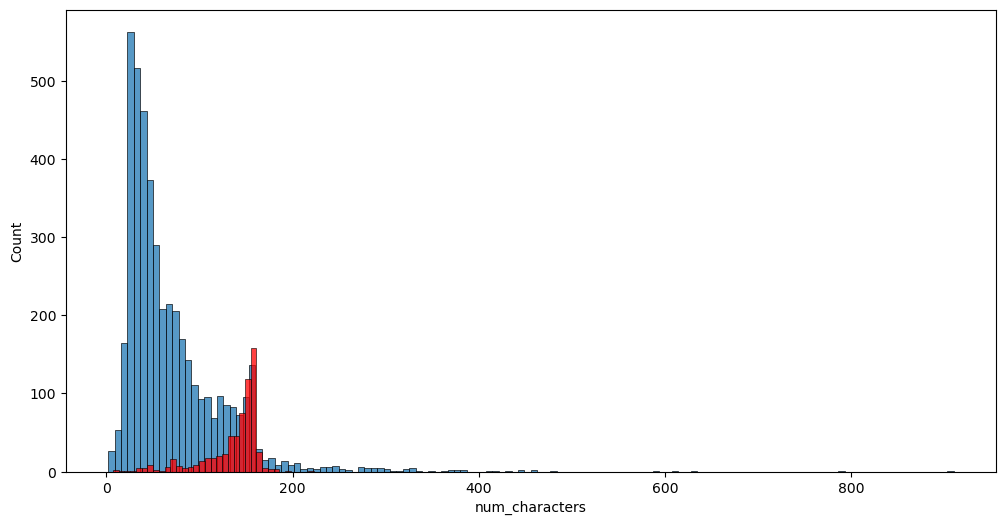

In [22]:
# visualizing the number of characters in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_characters'])
sns.histplot(df[df['Category'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

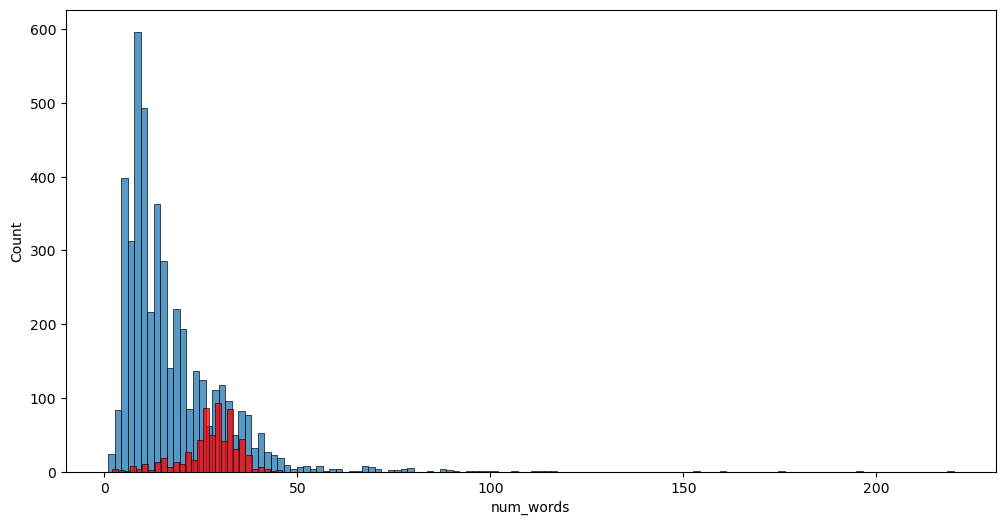

In [23]:
# visualizing the number of words in ham and spam messages
plt.figure(figsize=(12, 6))
sns.histplot(df[df['Category'] == 0]['num_words'])
sns.histplot(df[df['Category'] == 1]['num_words'], color='red')

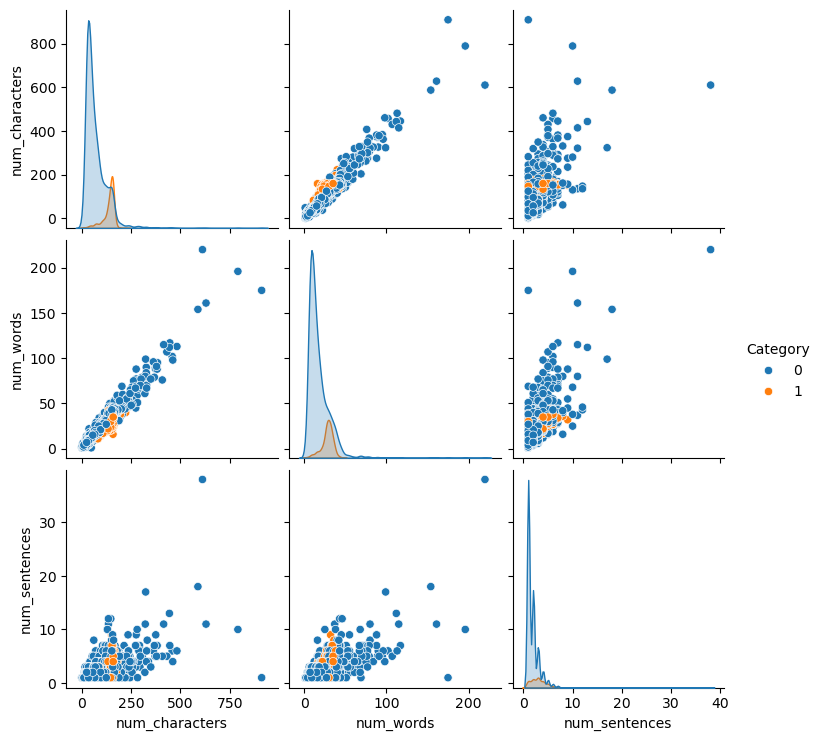

In [24]:
sns.pairplot(df, hue="Category")

<Axes: >

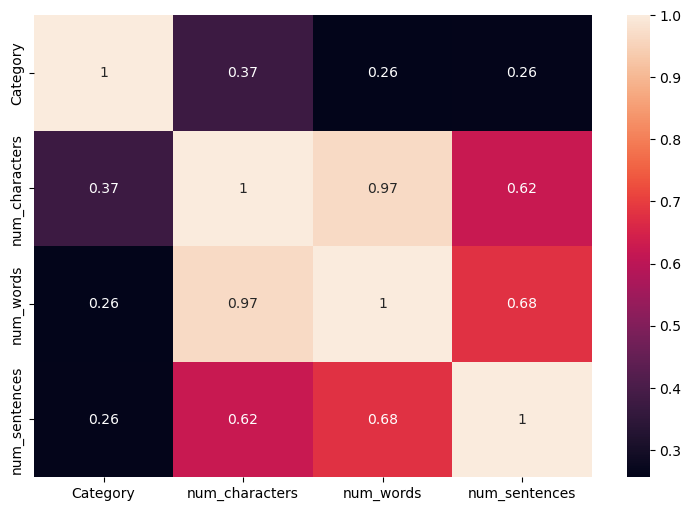

In [25]:
# visualizing the correlation between the new features
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Data Preprocessing :-

- Convert to lower case
- Tokenize the text
- Remove special characters
- Remove stop words and punctuations
- Stemming


In [26]:
# text preprocessing
import string
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
nltk.download('stopwords')


def transform_text(Message):
    # converting the text to lowercase
    Message = Message.lower()

    # tokenizing the text (breaking the text into words)
    Message = nltk.word_tokenize(Message)

    # removing the special characters and only keeping the alphanumeric characters
    y = []
    for i in Message:
        if i.isalnum():
            y.append(i)
    
    # removing the stop words and punctuation
    Message = y[:]
    y.clear()
    for i in Message:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    # stemming the words (removing the suffixes from the words)
    Message = y[:]
    y.clear()
    for i in Message:
        y.append(ps.stem(i))


    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
df['transformed_text'] = df['Message'].apply(transform_text)

In [31]:
df.sample(5)

,Category,Message,num_characters,num_words,num_sentences,transformed_text
3256,0,HI ITS KATE CAN U GIVE ME A RING ASAP XXX,41,11,1,hi kate u give ring asap xxx
1538,0,All sounds good. Fingers . Makes it difficult ...,53,11,3,sound good finger make difficult type
2523,0,Dunno lei... I might b eatin wif my frens... I...,80,22,3,dunno lei might b eatin wif fren ü wan eat wai...
5227,0,I re-met alex nichols from middle school and i...,71,15,1,alex nichol middl school turn deal
1087,0,I don't think he has spatula hands!,35,9,1,think spatula hand


In [32]:
# installing the wordcloud library
!pip install wordcloud

In [33]:
from wordcloud import WordCloud

In [34]:
wc = WordCloud(width=700, height=400, min_font_size=7, background_color='white')

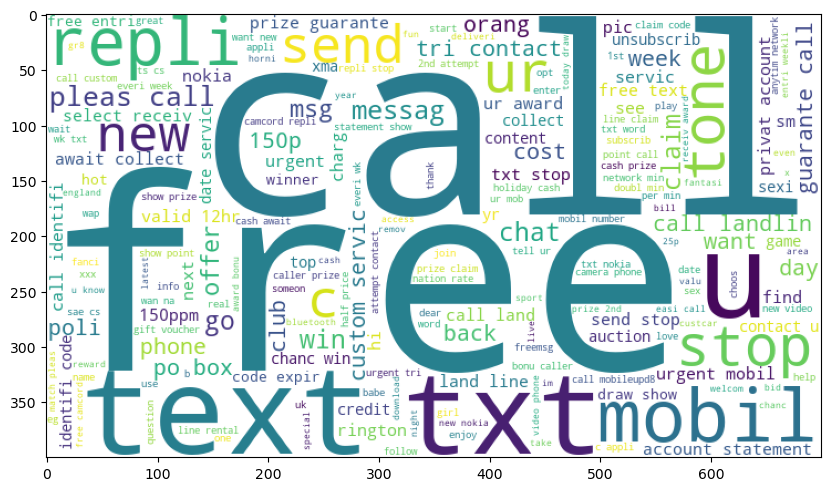

In [35]:
# generating the word cloud for spam messages
spam_wc = wc.generate(df[df['Category'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(spam_wc)

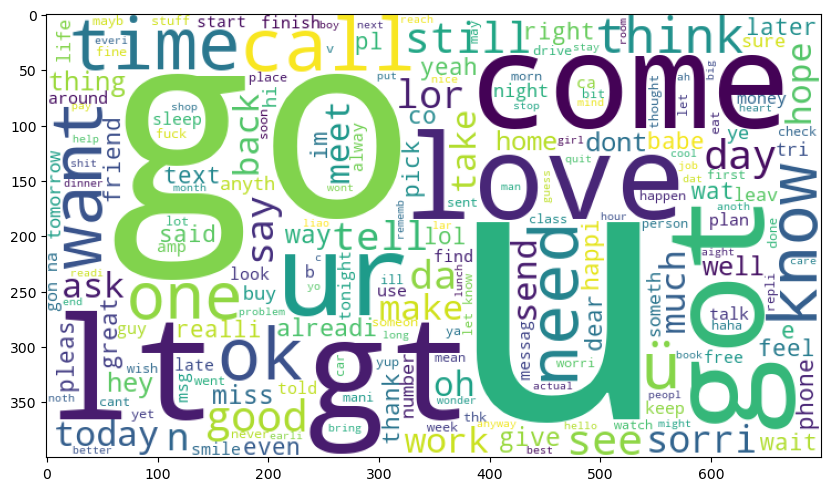

In [36]:
# generating the word cloud for ham messages
spam_wc = wc.generate(df[df['Category'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(10, 7))
plt.imshow(spam_wc)

In [37]:
# creating a corpus of all the words in the spam messages so that we can find the most occurring words in the spam messages

spam_corpus = []
for msg in df[df['Category'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [38]:
len(spam_corpus)

9781

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'ur'),
  Text(6, 0, 'u'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'send'),
  Text(17, 0, 'tone'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'award'),
  Text(20, 0, 'nokia'),
  Text(21, 0, 'contact'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'min'),
  Text(28, 0, 'c'),
  Text(29, 0, 'guarante')])

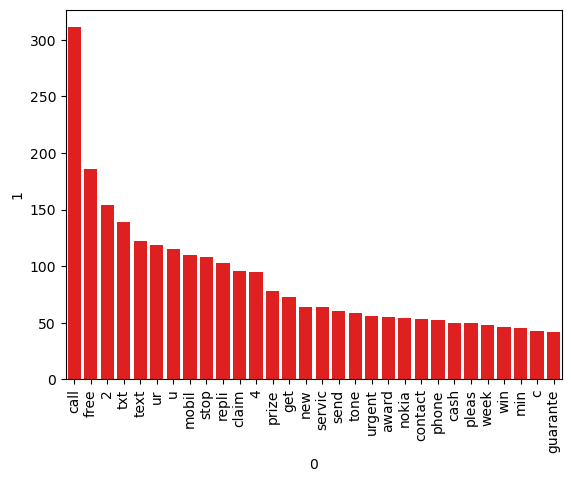

In [39]:
# for spam
from collections import Counter
sns.barplot(x = pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y = pd.DataFrame(Counter(spam_corpus).most_common(30))[1], color='red')
plt.xticks(rotation= 'vertical')

In [40]:
# creating a corpus of all the words in the ham messages so that we can find the most occurring words in the ham messages

ham_corpus = []
for msg in df[df['Category'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [41]:
len(ham_corpus)

35942

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, '2'),
  Text(4, 0, 'gt'),
  Text(5, 0, 'lt'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'call'),
  Text(11, 0, 'love'),
  Text(12, 0, 'time'),
  Text(13, 0, 'ok'),
  Text(14, 0, 'good'),
  Text(15, 0, 'want'),
  Text(16, 0, 'ur'),
  Text(17, 0, 'day'),
  Text(18, 0, 'ü'),
  Text(19, 0, 'need'),
  Text(20, 0, 'one'),
  Text(21, 0, '4'),
  Text(22, 0, 'lor'),
  Text(23, 0, 'home'),
  Text(24, 0, 'think'),
  Text(25, 0, 'see'),
  Text(26, 0, 'take'),
  Text(27, 0, 'still'),
  Text(28, 0, 'da'),
  Text(29, 0, 'tell')])

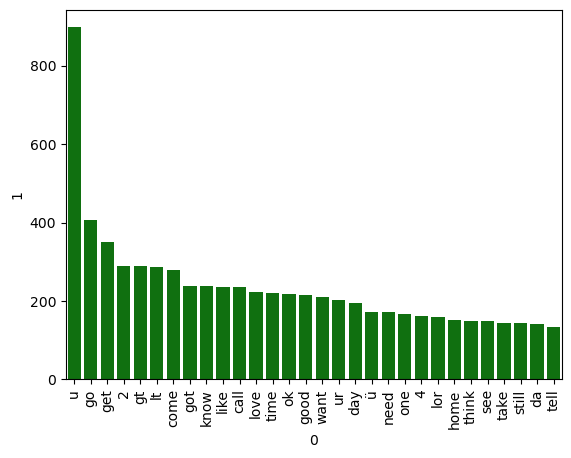

In [42]:
# for ham
sns.barplot(x = pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y = pd.DataFrame(Counter(ham_corpus).most_common(30))[1], color='green')
plt.xticks(rotation= 'vertical')

In [43]:
dfM = df.copy()

In [44]:
dfM.head()

,Category,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
# trasnforming the text data into numerical data using count vectorizer
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [46]:
X = cv.fit_transform(dfM['transformed_text']).toarray()

In [47]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5157, 6781))

In [48]:
y = dfM['Category'].values

In [49]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

In [50]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [51]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [52]:
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb = GaussianNB()

In [53]:
gnb.fit(X_train, y_train)
y_pred_1 = gnb.predict(X_test)
print("==== Gaussian Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_1), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_1), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_1), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_1), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_1), end ="\n\n")

==== Gaussian Naive Bayes ====
Accuracy: 0.8691860465116279

Confusion Matrix:
[[786 119]
 [ 16 111]]

Precision: 0.4826086956521739

Recall: 0.8740157480314961

F1 Score: 0.6218487394957983



In [54]:
mnb.fit(X_train, y_train)
y_pred_2 = mnb.predict(X_test)
print("==== Multinomial Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_2), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_2), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_2), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_2), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_2), end ="\n\n")

==== Multinomial Naive Bayes ====
Accuracy: 0.9796511627906976

Confusion Matrix:
[[895  10]
 [ 11 116]]

Precision: 0.9206349206349206

Recall: 0.9133858267716536

F1 Score: 0.9169960474308301



In [55]:
bnb.fit(X_train, y_train)
y_pred_3 = bnb.predict(X_test)
print("==== Bernoulli Naive Bayes ====")
print("Accuracy:", accuracy_score(y_test, y_pred_3), end ="\n\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3), end ="\n\n")
print("Precision:", precision_score(y_test, y_pred_3), end ="\n\n")
print("Recall:", recall_score(y_test, y_pred_3), end ="\n\n")
print("F1 Score:", f1_score(y_test, y_pred_3), end ="\n\n")

==== Bernoulli Naive Bayes ====
Accuracy: 0.9718992248062015

Confusion Matrix:
[[902   3]
 [ 26 101]]

Precision: 0.9711538461538461

Recall: 0.7952755905511811

F1 Score: 0.8744588744588745

